<a href="https://colab.research.google.com/github/kekeaii/machine_learning/blob/main/numerai/hello_numerai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hello, Numerai

Hello and welcome to the Numerai Data Science Tournament!

This notebook is designed to help you build your first machine learning model and start competing in the tournament.

In this notebook we will
1. Download and explore the Numerai dataset
2. Train your first machine learning model
3. Evaluate it with `CORR`, `MMC`, and `BMC`
4. Deploy it to start making live submissions

In [2]:
!python --version

Python 3.13.15


In [1]:
# Install dependencies
!pip install -q --upgrade numerapi pandas==2.3.1 pyarrow matplotlib lightgbm scikit-learn scipy cloudpickle==3.1.1

# Inline plots
%matplotlib inline

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 12.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 2.3.1 which is incompatible.


## 1. Dataset

The Numerai dataset is a tabular dataset that describes the stock market over time, compiled from high-quality (and expensive) data that would be difficult for individuals to obtain.

It is also `obfuscated`: stock ids, feature names, and target definitions are anonymized. This lets Numerai give the data out for free, and lets you model it without any financial domain knowledge (or bias!).

### Listing the datasets
Firstly, take a look at the files Numerai offers below:

In [3]:
# Initialize NumerAPI - the official Python API client for Numerai
from numerapi import NumerAPI
napi = NumerAPI()

# List the datasets and available versions
all_datasets = napi.list_datasets()
dataset_versions = list(set(d.split('/')[0] for d in all_datasets))
print("Available versions:\n", dataset_versions)

# Set data version to one of the latest datasets
DATA_VERSION = "v5.3"

# Print all files available for download for our version
current_version_files = [f for f in all_datasets if f.startswith(DATA_VERSION)]
print("Available", DATA_VERSION, "files:\n", current_version_files)

Available versions:
 ['v5.3', 'v5.2', 'v5.0', 'v5.1']
Available v5.3 files:
 ['v5.3/features.json', 'v5.3/live.parquet', 'v5.3/live_benchmark_models.parquet', 'v5.3/live_example_preds.csv', 'v5.3/live_example_preds.parquet', 'v5.3/meta_model.parquet', 'v5.3/train.parquet', 'v5.3/train_benchmark_models.parquet', 'v5.3/validation.parquet', 'v5.3/validation_benchmark_models.parquet', 'v5.3/validation_example_preds.csv', 'v5.3/validation_example_preds.parquet']


### Downloading datasets

The `features.json` file contains metadata about features in the dataset including:
- statistics on each feature
- helpful sets of features
- the targets available for training

Let's download it and take a look:

In [4]:
import json

# Download the feature metadata file
napi.download_dataset(f"{DATA_VERSION}/features.json")

# Read the metadata and display
feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))
for metadata in feature_metadata:
  print(metadata, len(feature_metadata[metadata]))

v5.3/features.json: 100%|██████████| 387k/387k [00:00<00:00, 1.31MB/s]

feature_sets 19
targets 41


### Feature Sets & Groups
As you can see there are many features and targets to choose from.

Instead of training a model on all 2000+ features, let's pick a subset of features to analyze.

Here are a few starter sets Numerai offers:

- `small` contains a minimal subset of features that have the highest [feature importance](https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html)

- `medium` contains all the "basic" features, each unique in some way (e.g. P/E ratios vs analyst ratings)

- `faith` contains a focused set of features released during the v5.1/2 dataset eras

- `quantum` contains a set of 807 new features released in v5.3

- `all` contains all features in `medium` and their variants (e.g. P/E by country vs P/E by sector)

Let's compare their sizes:

In [5]:
feature_sets = feature_metadata["feature_sets"]
for feature_set_name in ["small", "medium", "faith", "quantum", "all"]:
  print(feature_set_name, len(feature_sets[feature_set_name]))

small 42
medium 780
faith 372
quantum 807
all 3555


We will use the `faith` feature set.

For this notebook, we will train on every available training era. Using all eras takes longer and requires more memory, but it gives us the most representative validation results.

In [6]:
import pandas as pd

# Define our feature set
feature_set = feature_sets["faith"]
# Use "medium" or "all" for broader feature coverage, or "quantum" for the latest features.
# These alternatives require more RAM.
# feature_set = feature_sets["small"]
# feature_set = feature_sets["medium"]
# feature_set = feature_sets["all"]
# feature_set = feature_sets["quantum"]

# Download the training data - this will take a few minutes
napi.download_dataset(f"{DATA_VERSION}/train.parquet")

# Load the features and the payout target for every training era, along with
# the previous 20-day payout target for a comparison later
train = pd.read_parquet(
    f"{DATA_VERSION}/train.parquet",
    columns=["era", "target", "target_ender_20"] + feature_set
)

v5.3/train.parquet: 100%|██████████| 3.30G/3.30G [01:57<00:00, 28.1MB/s]


### Training data

Each row represents a stock at a specific point in time:
- `id` is the stock id
- `era` is the date
- `target` is a measure of future returns for that stock
- `features` describe the attributes of the stock (e.g. P/E ratio) for that date

In [7]:
train

,era,target,target_ender_20,feature_acadian_lamelliform_forefoot,feature_acarine_personate_survivor,feature_accredited_consummate_currie,feature_adamantine_cosmogonical_stringing,feature_adipose_bighearted_diabolo,feature_aerodynamical_exhibitive_keyword,feature_aeronautical_fourteenth_neurectomy,...,feature_vorticose_decrescent_gliwice,feature_warrigal_ethic_reperusal,feature_wary_unverified_drip,feature_weightier_entomostracan_yale,feature_wiggly_busiest_nymphomania,feature_wily_supposed_grumphie,feature_wintry_multiscreen_adonic,feature_wiretap_discoidal_septette,feature_xanthic_contending_noblewoman,feature_zany_insufferable_allegiance
id,,,,,,,,,,,,,,,,,,,,,
n0007b5abb0c3a25,0001,0.25,0.25,2,2,2,1,2,1,2,...,2,2,2,2,2,2,2,2,2,2
n003bba8a98662e4,0001,0.50,0.50,2,2,2,3,2,2,2,...,2,2,2,2,2,2,2,2,2,2
n003bee128c2fcfc,0001,1.00,1.00,2,2,2,0,2,4,2,...,2,1,2,2,2,2,4,2,2,2
n0048ac83aff7194,0001,0.00,0.25,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
n0055a2401ba6480,0001,0.50,0.50,2,2,2,4,2,0,2,...,2,4,2,2,2,2,0,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nffcc1dbdf2212e6,0574,0.75,0.50,0,3,0,0,1,1,2,...,2,1,2,4,4,4,0,0,3,2
nffde3b371d67394,0574,0.75,0.50,4,4,0,0,4,1,2,...,2,3,2,3,1,0,1,0,3,2
nfff1a1111b35e84,0574,0.50,0.50,2,0,2,2,0,2,2,...,2,2,2,2,4,2,2,2,0,2


### Eras
Each `era` corresponds to a different date, exactly 1 week apart.

Think of the rows within an `era` as a single example - throughout these notebooks we score everything "per era". The rows per era below trace the size of Numerai's investable universe over time.

<Axes: title={'center': 'Number of rows per era'}, xlabel='Era'>

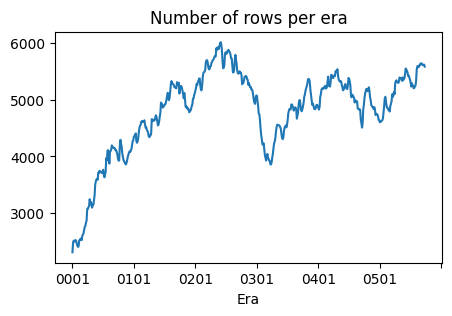

In [8]:
# Plot the number of rows per era
train.groupby("era").size().plot(
    title="Number of rows per era",
    figsize=(5, 3),
    xlabel="Era"
)

### Target
The `target` is a measure of "stock-specific" returns over the next 60 (business) days - returns not explained by well-known "factors" or broader trends in the market, country, or sector. For example, if Apple went up and the tech sector also went up, we only want to know if Apple went up more or less than the tech sector.

Target values are binned into 5 unequal bins: `0`, `0.25`, `0.5`, `0.75`, `1.0`. This heavy regularization avoids overfitting because the underlying values are extremely noisy.

*Until recently, payouts were based on a 20-day version of this target (`target_ender_20`) - we loaded it above and will compare the two later.*

<Axes: title={'center': 'Target'}, xlabel='Value', ylabel='Frequency'>

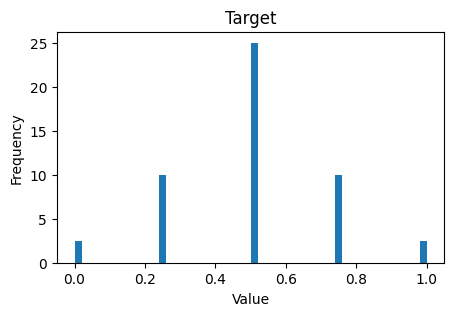

In [9]:
# Plot density histogram of the target
train["target"].plot(
  kind="hist",
  title="Target",
  figsize=(5, 3),
  xlabel="Value",
  density=True,
  bins=50
)

### Features
The `features` are quantitative attributes of each stock: fundamentals like P/E ratio, technical signals like RSI, market data like short interest, analyst ratings, and much more. Their definitions aren't important - Numerai includes them because we believe they help predict the `target`.

When available, feature values are binned into 5 equal-frequency integer bins: `0`, `1`, `2`, `3`, `4`. When a feature is missing for an era, that entire feature-era is filled with the middle bin `2`.

The Faith features are relatively new, so their history varies. The feature below has no training history and is regularly populated from era `1108` - compare its first populated era with the missing era just before it:

v5.3/validation.parquet: 100%|██████████| 5.66G/5.66G [03:20<00:00, 28.2MB/s]


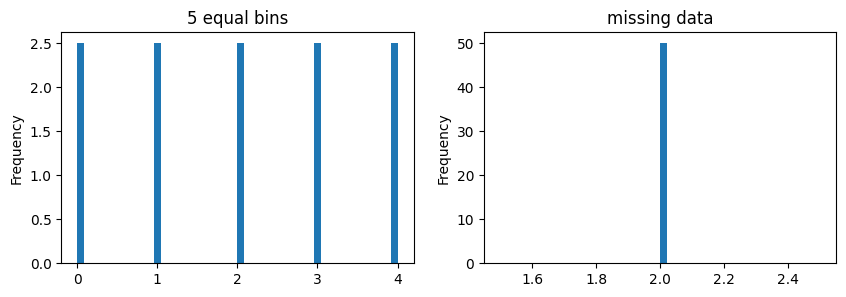

In [10]:
import matplotlib.pyplot as plt

# feature_set[-1] is unavailable in train, so use validation history to find
# the first era from which this feature is regularly populated.
feature_to_plot = feature_set[-1]
napi.download_dataset(f"{DATA_VERSION}/validation.parquet")
faith_feature_history = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", feature_to_plot],
    # push the row filter into the read itself so we never load rows we don't need
    filters=[("data_type", "==", "validation")],
)

# A populated era has more than one unique value. For this feature, every era
# from the first populated era onward has all five bins.
unique_values_by_era = faith_feature_history.groupby("era")[feature_to_plot].nunique()
covered_eras = unique_values_by_era.index[unique_values_by_era > 1]
first_covered_era = covered_eras[0]
first_covered_position = unique_values_by_era.index.get_loc(first_covered_era)
previous_missing_era = unique_values_by_era.index[first_covered_position - 1]

assert first_covered_era == "1108"
assert (unique_values_by_era.loc[first_covered_era:] == 5).all()
assert unique_values_by_era.loc[previous_missing_era] == 1

first_regular_era = faith_feature_history[
    faith_feature_history["era"] == first_covered_era
]
previous_missing_data_era = faith_feature_history[
    faith_feature_history["era"] == previous_missing_era
]

# Use the same histogram settings as the original notebook, but select eras
# based on this Faith feature's actual availability.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
first_regular_era[feature_to_plot].plot(
   title="5 equal bins",
   kind="hist",
   density=True,
   bins=50,
   ax=ax1
)
previous_missing_data_era[feature_to_plot].plot(
   title="missing data",
   kind="hist",
   density=True,
   bins=50,
   ax=ax2
)

del faith_feature_history

## 2. Modeling
Our task: predict the `target` using the `features`.

### Model training

You are free to use any tool or framework, but here we use LightGBM - a popular choice amongst tournament participants. While your model trains, watch this [video](https://www.youtube.com/watch?v=w8Y7hY05z7k) from our Chief Scientist MDO on why tree-based models work so well on tabular data.

In [11]:
# https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html
import lightgbm as lgb

# https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html
model = lgb.LGBMRegressor(
  n_estimators=2000,
  learning_rate=0.01,
  max_depth=5,
  num_leaves=2**5-1,
  colsample_bytree=0.1
)
# We've found the following "deep" parameters perform much better, but they require much more CPU and RAM
# model = lgb.LGBMRegressor(
#     n_estimators=30_000,
#     learning_rate=0.001,
#     max_depth=10,
#     num_leaves=2**10,
#     colsample_bytree=0.1,
#     min_data_in_leaf=10000,
# )

# This will take a few minutes per model 🍵
model.fit(
  train[feature_set],
  train["target"]
)

# Train the same model on the previous 20-day payout target
# so we can compare the two targets later
model_20day = lgb.LGBMRegressor(**model.get_params())
model_20day.fit(
  train[feature_set],
  train["target_ender_20"]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.192855 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1335
[LightGBM] [Info] Number of data points in the train set: 2746268, number of used features: 267
[LightGBM] [Info] Start training from score 0.499948
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


KeyboardInterrupt: 

In [12]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


### Validation predictions

Now let's make out-of-sample predictions on the validation dataset.

Validation is even bigger than train, so to stay within Colab's ~12GB of RAM we free the training data, filter rows during the parquet read, and predict one era at a time.

In [ ]:
# Eras are 1 week apart, but the target looks 60 days (about 12 weeks/eras) into the future,
# so we embargo the first 12 eras following our last train era to avoid data leakage.
last_train_era = int(train["era"].unique()[-1])
eras_to_embargo = [str(last_train_era + i).zfill(4) for i in range(1, 13)]

# We are done training - free the training data to make room for validation
# (to re-train later, just re-run the cells above)
del train

# Load the validation data, filtering during the read so the embargoed eras and
# the rows reserved for Numerai's test set never take up memory
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "target", "target_ender_20"] + feature_set,
    filters=[
        ("data_type", "==", "validation"),
        ("era", "not in", eras_to_embargo),
    ],
)

# Generate predictions one era at a time - predicting on the entire validation
# set in a single call would take several times more memory than Colab offers
# This will take a few minutes 🍵
predictions, predictions_20day = [], []
for era, era_data in validation.groupby("era"):
    era_features = era_data[feature_set]
    predictions.append(pd.Series(model.predict(era_features), index=era_data.index))
    predictions_20day.append(pd.Series(model_20day.predict(era_features), index=era_data.index))
validation["prediction"] = pd.concat(predictions)
validation["prediction_20day"] = pd.concat(predictions_20day)

# The features have done their job - keep only the columns we need for scoring
validation = validation[["era", "prediction", "prediction_20day", "target", "target_ender_20"]]
validation

### Performance evaluation

Numerai's scores are designed to "align incentives": a model with good scores should help the hedge fund make good returns.

- `CORR` (`numerai_corr`): a Numerai-specific correlation between your predictions and the target.

- `MMC` (`correlation_contribution`): how uniquely additive your model is to the Numerai Meta Model.

- `BMC` (also `correlation_contribution`): how uniquely additive your model is beyond Numerai's public benchmark models.

We'll start with `CORR`, then see why `MMC` is hard to backtest and why `BMC` might be a better research objective.

In [ ]:
# Install Numerai's open-source scoring tools
!pip install -q --no-deps numerai-tools

# Import the CORR scoring function
from numerai_tools.scoring import numerai_corr

### CORR: correlation with the target

`CORR` is the main "is this model directionally right?" metric - a proxy for portfolio returns if your predictions were used in live trading. Positive `CORR` means your model is aligned with Numerai's strategy.

*Note: on the Numerai website, older rounds show `CORR20V2` - those were scored on the previous 20-day target.*

Always score each `era` independently - "per era" metrics are what matter, not one score across the whole validation set.

And yes, the scores are low: +/- 0.05 is normal in quantitative finance. This is why we call Numerai the "hardest data science tournament on the planet".

In [ ]:
# Compute the per-era CORR between our predictions and target values
per_era_corr = (
    validation.dropna(subset=["prediction", "target"])
    .groupby("era")[["prediction", "target"]]
    .apply(
        lambda era_data: numerai_corr(
            era_data[["prediction"]],
            era_data["target"]
        )
    )["prediction"]
)

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot the per-era correlation
per_era_corr.plot(
    title="Validation CORR",
    kind="bar",
    ax=axes[0],
    xticks=[],
    legend=False,
    snap=False
)

# Plot the cumulative per-era correlation
per_era_corr.cumsum().plot(
    title="Cumulative Validation CORR",
    kind="line",
    ax=axes[1],
    legend=False
)

plt.tight_layout()
plt.show()

Cumulative `CORR` is easier to read than the raw per-era scores - think of it as a rough backtest of your model's target alignment over the validation period.

Notice it climbs steadily, even for this simple model on modern data.

### CORR summary metrics

A few summary metrics over the entire validation period:

- `Mean`: long-term performance.

- `Sharpe`: consistency - mean divided by standard deviation.

- `Max drawdown`: risk - the largest peak-to-trough drop in cumulative score.

In [ ]:
# Compute CORR performance metrics
corr_mean = per_era_corr.mean()
corr_std = per_era_corr.std(ddof=0)
corr_sharpe = corr_mean / corr_std
corr_max_drawdown = (
    per_era_corr.cumsum().expanding(min_periods=1).max()
    - per_era_corr.cumsum()
).max()

pd.DataFrame({
    "mean": [corr_mean],
    "std": [corr_std],
    "sharpe": [corr_sharpe],
    "max_drawdown": [corr_max_drawdown]
}, index=["CORR"]).T

### MMC: Meta Model Contribution

`MMC` measures whether your model adds signal after neutralizing away everything it shares with the Meta Model.

Careful, though: the Meta Model is a moving target - it changes as the crowd adopts new data and modeling ideas.

In [ ]:
# Import the contribution scoring function used for both MMC and BMC
from numerai_tools.scoring import correlation_contribution

# Download and join the current v5.3 Meta Model for the validation eras
napi.download_dataset(f"{DATA_VERSION}/meta_model.parquet")
validation["current_meta_model"] = pd.read_parquet(
    f"{DATA_VERSION}/meta_model.parquet",
    columns=["numerai_meta_model"]
)["numerai_meta_model"]

# Compute per-era MMC against the current v5.3 Meta Model
per_era_mmc_current = (
    validation.dropna(
        subset=["prediction", "target", "current_meta_model"]
    )
    .groupby("era")[["prediction", "current_meta_model", "target"]]
    .apply(
        lambda era_data: correlation_contribution(
            era_data[["prediction"]],
            era_data["current_meta_model"],
            era_data["target"]
        )
    )["prediction"]
)

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot the per-era MMC
per_era_mmc_current.plot(
    title="Validation MMC",
    kind="bar",
    ax=axes[0],
    xticks=[],
    legend=False,
    snap=False
)

# Plot cumulative per-era MMC
per_era_mmc_current.cumsum().plot(
    title="Cumulative Validation MMC",
    kind="line",
    ax=axes[1],
    legend=False
)

plt.tight_layout()
plt.show()

Cumulative `MMC` rises steadily - this model looks consistently additive.

But there is a catch: the Faith features only became public partway through this window, so for most of the backtest above, the crowd behind the Meta Model didn't have them yet.

Watch what happens if we repeat the exact same backtest with the previous 20-day payout target:

In [ ]:
# Score the 20-day model against the Meta Model on the previous payout target
per_era_mmc_20day = (
    validation.dropna(
        subset=["prediction_20day", "target_ender_20", "current_meta_model"]
    )
    .groupby("era")[["prediction_20day", "current_meta_model", "target_ender_20"]]
    .apply(
        lambda era_data: correlation_contribution(
            era_data[["prediction_20day"]],
            era_data["current_meta_model"],
            era_data["target_ender_20"]
        )
    )["prediction_20day"]
)

# Compare cumulative MMC under the two payout targets
fig, axis = plt.subplots(figsize=(10, 4))
per_era_mmc_20day.cumsum().plot(ax=axis, label="20-day target (ender_20)")
per_era_mmc_current.cumsum().plot(ax=axis, label="60-day target (ender_60)")
faith_release = per_era_mmc_20day.index.get_loc("1192")
axis.axvline(faith_release, color="black", linestyle="--", linewidth=1, label="Faith released")
axis.set_title("Cumulative MMC by payout target")
axis.set_xlabel("era")
axis.legend()
plt.tight_layout()
plt.show()

On the 20-day target, contribution peaks almost exactly at the Faith release, then fades as the crowd adopts the same data.

The 60-day line keeps climbing, but be careful: it is mainly showing that a model trained on the 60-day target (`ender_60`) is additive to the Meta Model's correlation with that target, because the Meta Model here is still built from a crowd that was paid on - and therefore trained on - the 20-day target (`ender_20`). Once payouts switch to the 60-day target and everyone retrains, expect this line to sink just like the 20-day line did after the Faith release.

The lesson: an MMC backtest compares you against yesterday's crowd - one that hadn't yet seen your data or adopted your target. It can explain the past, but it is not a reliable objective to optimize.

### BMC: Benchmark Model Contribution

`BMC` uses the same `correlation_contribution` calculation as `MMC`, but replaces the ever-changing Meta Model with a fixed public benchmark. Offline Diagnostics uses the benchmark trained on the payout target, so we use `v53_lgbm_ender60` here.

This makes `BMC` a practical research objective: does your model add signal beyond a strong, modern benchmark that anyone can download?

In [ ]:
# Download the validation benchmark predictions used by Diagnostics
BENCHMARK_MODEL = "v53_lgbm_ender60"
napi.download_dataset(f"{DATA_VERSION}/validation_benchmark_models.parquet")
validation["benchmark_model"] = pd.read_parquet(
    f"{DATA_VERSION}/validation_benchmark_models.parquet",
    columns=[BENCHMARK_MODEL]
)[BENCHMARK_MODEL]

# Calculate BMC for the validation eras covered by the benchmark
per_era_bmc_current = (
    validation.dropna(
        subset=["prediction", "target", "benchmark_model"]
    )
    .groupby("era")[["prediction", "benchmark_model", "target"]]
    .apply(
        lambda era_data: correlation_contribution(
            era_data[["prediction"]],
            era_data["benchmark_model"],
            era_data["target"]
        )
    )["prediction"]
)

### BMC as an offline proxy for MMC

Each point below is one Meta Model era. The upward-sloping cloud shows that `BMC` and `MMC` tend to move together even though they are calculated against different references - a useful directional proxy, though not a guarantee of the same numerical level.

In [ ]:
# Align current v5.3 MMC and BMC by era
current_mmc_bmc = pd.concat(
    [per_era_mmc_current.rename("MMC"), per_era_bmc_current.rename("BMC")],
    axis=1
).dropna()

# Plot per-era current MMC against BMC
fig, axis = plt.subplots(figsize=(7, 5))
axis.scatter(current_mmc_bmc["BMC"], current_mmc_bmc["MMC"], alpha=0.6, s=24)
limits = [
    current_mmc_bmc[["MMC", "BMC"]].min().min(),
    current_mmc_bmc[["MMC", "BMC"]].max().max(),
]
axis.plot(limits, limits, color="black", linestyle="--", linewidth=1, label="BMC = MMC")
axis.axhline(0, color="black", linewidth=0.7)
axis.axvline(0, color="black", linewidth=0.7)
axis.set_title(
    "Faith model on current v5.3 Meta Model eras\n"
    f"correlation = {current_mmc_bmc['MMC'].corr(current_mmc_bmc['BMC']):.3f}"
)
axis.set_xlabel("BMC")
axis.set_ylabel("MMC")
axis.legend()
plt.tight_layout()
plt.show()

### BMC validation performance

Since `BMC` tracks `MMC` directionally, we can use it the way Diagnostics does: as an offline report card for contribution. Better yet, the fixed benchmark is published for the entire validation window, while the Meta Model only exists for the most recent eras - so `BMC` gives us a much longer backtest:

In [ ]:
# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot the per-era BMC
per_era_bmc_current.plot(
    title="Validation BMC",
    kind="bar",
    ax=axes[0],
    xticks=[],
    legend=False,
    snap=False
)

# Plot cumulative per-era BMC
per_era_bmc_current.cumsum().plot(
    title="Cumulative Validation BMC",
    kind="line",
    ax=axes[1],
    legend=False
)

plt.tight_layout()
plt.show()

Over this longer window, cumulative `BMC` still trends up, but the extra history is sobering: there are multi-year flat stretches and real drawdowns that the short Meta Model window above never shows.

### Current contribution summary metrics

The table below compares MMC and BMC on the same current v5.3 Meta Model eras.

In [ ]:
contribution_scores = {
    "MMC vs current v5.3 Meta Model": current_mmc_bmc["MMC"],
    "BMC on current v5.3 eras": current_mmc_bmc["BMC"],
}

contribution_summary = pd.DataFrame({
    name: {
        "eras": len(scores),
        "mean": scores.mean(),
        "std": scores.std(ddof=0),
        "sharpe": scores.mean() / scores.std(ddof=0),
        "max_drawdown": (scores.cumsum().cummax() - scores.cumsum()).max(),
    }
    for name, scores in contribution_scores.items()
}).T
contribution_summary

These metrics don't need to be amazing - we're just getting started. The next tutorials cover improving target prediction while adding unique signal beyond public benchmarks.

## 3. Submissions

Unlike Kaggle competitions that evaluate models on <ins>test</ins> performance, Numerai evaluates models on <ins>live</ins> performance.

### Live predictions

Every Tuesday-Saturday, new `live features` are released - the current state of the stock market. Your job is to predict the target: stock-specific returns 60 days into the future.

In [ ]:
# Download latest live features
napi.download_dataset(f"{DATA_VERSION}/live.parquet")

# Load live features
live_features = pd.read_parquet(f"{DATA_VERSION}/live.parquet", columns=feature_set)

# Generate live predictions
live_predictions = model.predict(live_features[feature_set])

# Format submission
pd.Series(live_predictions, index=live_features.index).to_frame("prediction")

### Model upload

To participate in the tournament, you must submit live predictions every Tuesday-Saturday.

To automate this process, you can simply:
- Define your prediction pipeline as a function
- Serialize your function using the `cloudpickle` library
- Upload your model pickle file to Numerai
- Let Numerai run your model to submit live predictions every day

Read more about Model Uploads and other self-hosted automation options in our [docs](https://docs.numer.ai/numerai-tournament/submissions#automation).

In [ ]:
# Define your prediction pipeline as a function
def predict(live_features: pd.DataFrame) -> pd.DataFrame:
    live_predictions = model.predict(live_features[feature_set])
    submission = pd.Series(live_predictions, index=live_features.index)
    return submission.to_frame("prediction")

In [ ]:
# Use the cloudpickle library to serialize your function
import cloudpickle
p = cloudpickle.dumps(predict)
with open("hello_numerai.pkl", "wb") as f:
    f.write(p)

In [ ]:
# Download file if running in Google Colab
try:
    from google.colab import files
    files.download('hello_numerai.pkl')
except:
    pass

That's it! You now have a pickle file that is ready for upload.

Head back to the [Tournament Basics onboarding step](https://numer.ai/onboarding/tournament-basics) to upload your model!